In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker
from pprint import pprint

import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

plot_dir = './plots'
latex = True

In [2]:
config1 = dict(
    # input_filename = 'hessian120k16k_eigs.npz',
    # input_filename = 'hessian_pb_eigs.npz',  # half powers of 2
    input_filename = 'hessian_eigs_2.npz',  # half powers of 2
    deg_m = 3,
    effective_n = 80_000,
    xlim = (-1, 7),
    ylim = [(0, 2.2), (0, 2.2), (0, 2.2)],
    nbins = (80, 200),
    label_mode = 'pow-dec',
    save_filename = 'hessian',
)

# -------

# config = config1
# config = config2
config = config1

Idx   Size   Repeat
---  -----   ------
0     1024       16
1     1448       11
2     2048        8
3     2896        5
4     4096        4
5     5792        2
6     8192        2
7    11585        1
8    16384        1
9    23170        1
10   32768        1

proc name: AMD Ryzen 7 5800X 8-Core Processor
num proc:  16
date:      2026-04-30 10:51:43 AEST



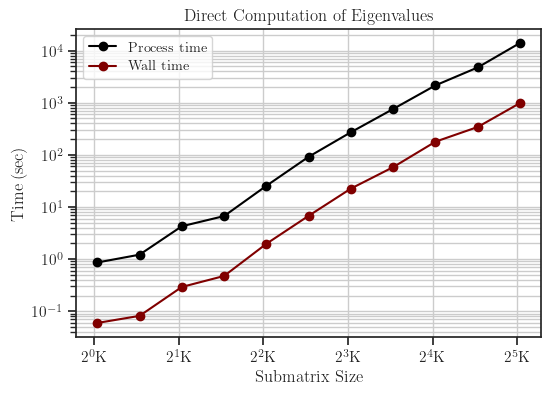

In [3]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
repeats = out['repeats']             # Repeats of sampling
eigs_repeated = out['eigs']          # List of eigenvalues per each submatrix
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)
proc_name = out['proc_name']
num_proc = out['num_proc']
date = out['date']

# concatenate all repeats
max_repeat = 1
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
print(f'proc name: {proc_name}')
print(f'num proc:  {num_proc}')
print(f'date:      {date}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

Plot saved to "/home/sia/work/github/freealg/notebooks/hessia_pb_ridge.pdf".


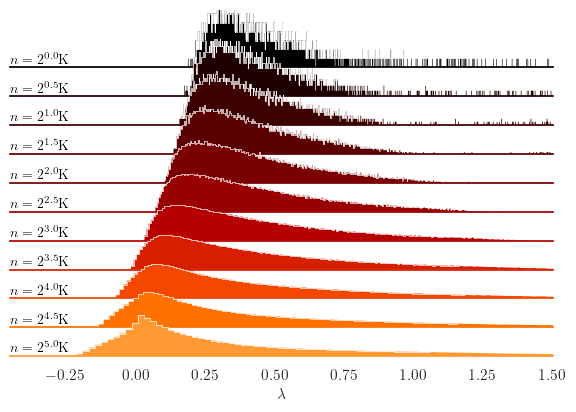

In [8]:
# eigs_no_atom = [None] * len(eigs)
# tol = 1e-4
# for i in range(len(eigs)):
#     eigs_no_atom[i] = eigs[i][numpy.abs(eigs[i]) > tol]

ridgeplot(sizes,
          # eigs=eigs_no_atom,
          eigs=eigs,
          log=False, scaley=False, hspace=-0.5, #-0.9,
          text_side='left',
          xlim=(-0.45, 1.5), ylim=(0, 3),
          # xlim=(-0.5, 25), ylim=(0, 0.05),
          figsize=(7, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, title='',
          save='hessia_pb_ridge.pdf', nbins=1000)

# Fit Spectral Curves


------------------------------------------
Support (detected from histogram):
| bulk 1 | interval: (  0.10625,   1.14260) | center:   0.62443 |  mass: 96.85% |
| bulk 2 | interval: (  1.19714,   1.22442) | center:   1.21078 |  mass:  0.02% |
| bulk 3 | interval: (  1.60623,   1.63350) | center:   1.61987 |  mass:  0.02% |
| bulk 4 | interval: (  1.71532,   1.79714) | center:   1.75623 |  mass:  0.07% |
| bulk 5 | interval: (  1.85168,   1.87895) | center:   1.86532 |  mass:  0.02% |
| bulk 6 | interval: (  1.93350,   1.96077) | center:   1.94713 |  mass:  0.02% |
| bulk 7 | interval: (  2.01531,   2.06986) | center:   2.04259 |  mass:  0.05% |
| bulk 8 | interval: (  2.20622,   2.50622) | center:   2.35622 |  mass:  0.61% |
| bulk 9 | interval: (  2.53349,   2.58803) | center:   2.56076 |  mass:  0.10% |
| bulk 10 | interval: (  2.66985,   2.72440) | center:   2.69712 |  mass:  0.05% |
| bulk 11 | interval: (  2.75167,   2.94257) | center:   2.84712 |  mass:  0.46% |
| bulk 12 | inter

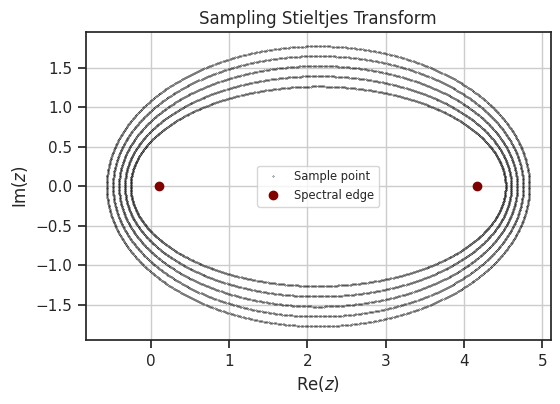

In [4]:
# Index to choose the initial sub-matrix size
start_idx = 4

# Detect support from histogram
print('\n------------------------------------------')
print('Support (detected from histogram):')
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=False,
                      print_info=True)

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 1000,
    max_subdivide = 20,
    anchor_mode = 'empirical',   # empirical, asymptotic
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    # anchor_y = 0.02,  # TEST
    anchor_y = 0.02,  # TEST
    # anchor_y = 1.1,
    anchor_y_max = 5.0,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.02,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.5,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes options
inv_stieltjes_opt = dict(
    # delta = 1e-6, # TEST
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 1,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'direct',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'uniform',  # 'uniform, small_delta
)

# Estimate the initia ratio "c0" from "c" of the larger matrix
ratio = sizes[start_idx] / config['effective_n']

# Main object
af = AlgebraicForm(eigs[start_idx],
                   ratio=ratio,
                   # support=None,
                   # support=[(0.1, 1.2), (1.7, 5)],
                   # support=[(0.1, 5)],
                   # support=support,
                   n=sizes[start_idx],
                   log=False,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# Polynomial degrees
# deg_m = config['deg_m']
# deg_z = 2
deg_m, deg_z = 8, 4

# Moments to be used as constraints in fitting
deg_mu = 2
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

print('\n------------------------------------------')
coeffs = af.fit(
    deg_m, deg_z, reg=0,
    # r_min=1.8, r_max=2.2, n_r=5,
    # r_min=1.5, r_max=3.0, n_r=10,
    r_min=1.8, r_max=2.2, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096 // 4,
    cut_eps=0.01,
    # normalize=True,
    # triangular=None,
    triangular=(-2, None),
    mu=mu,
    # mu='auto',
    mu_reg=None, verbose=True, plot=True)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')

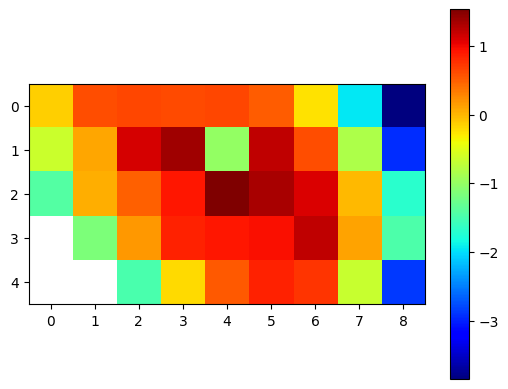

In [5]:
%matplotlib inline

p = plt.imshow(numpy.log10(numpy.abs(af.coeffs.real)), cmap=plt.cm.jet)
plt.colorbar(p)
plt.show()

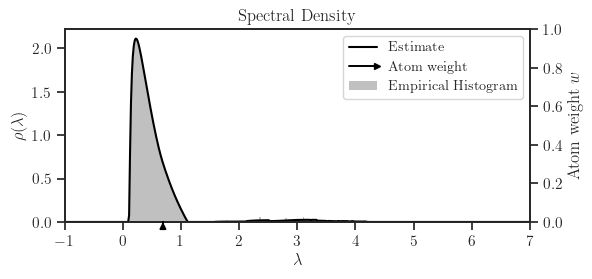

mass: 1.000558


In [6]:
x_min, x_max = config['xlim']
x0 = numpy.linspace(x_min, x_max, 500)
rho0 = af.density(x0, plot=True, latex=latex)

mass = numpy.trapz(rho0, x0)
print('mass: %f' % mass)

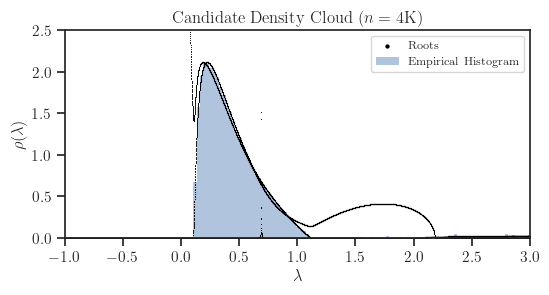

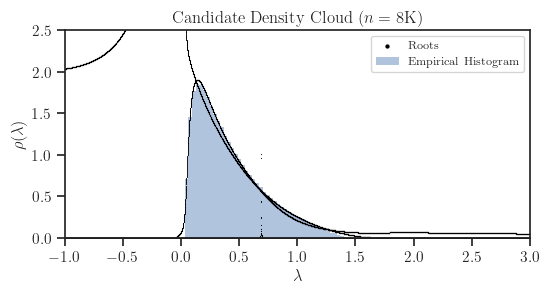

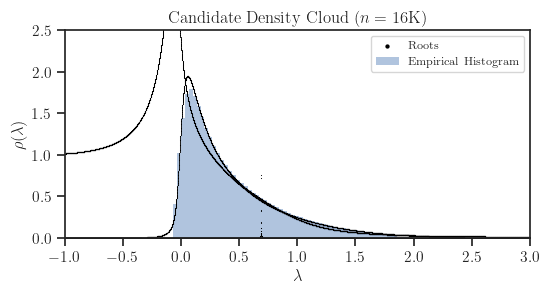

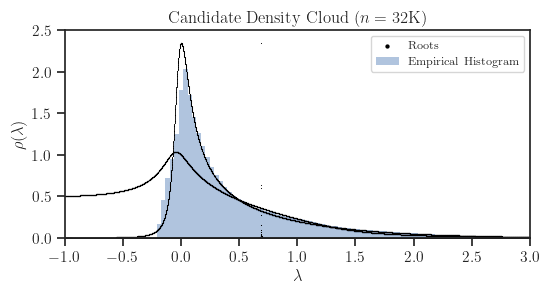

In [7]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
# x_min, x_max = config['xlim']
x_min, x_max = -1, 3
# x_highres = numpy.geomspace(x_min, x_max, 2000)
x_highres = numpy.linspace(x_min, x_max, 10000)
# for idx in [start_idx, start_idx+1, sizes.size-1]:
for idx in range(start_idx, sizes.size, 2):
    # ylim = (0, 0.06) if idx == sizes.size - 1 else None
    e = eigs[idx]
    h = numpy.histogram(e, 100, density=True)[0]
    ylim = (0, 1.1 * float(numpy.max(h[5:])))
    af.candidates(
        size=sizes[idx],
        kind='free',
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6,
        # ylim=ylim,
        ylim=(0, 2.5),
        latex=latex)

# Free Decompression

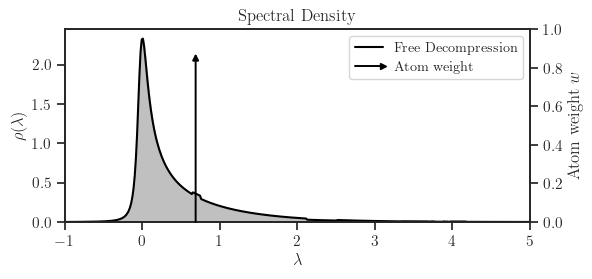

In [8]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
# x_min = 1e-5
# x_max = 1e3
# x_min, x_max = config['xlim']
x_min, x_max = -1, 5
x = numpy.linspace(x_min, x_max, 400)

newton_opt = dict(
    dt_max=0.0001,
    dt_min=1e-10,
    tol=1e-10,
    max_iter=200,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=1000,
    newton_opt=newton_opt, return_atoms=False, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

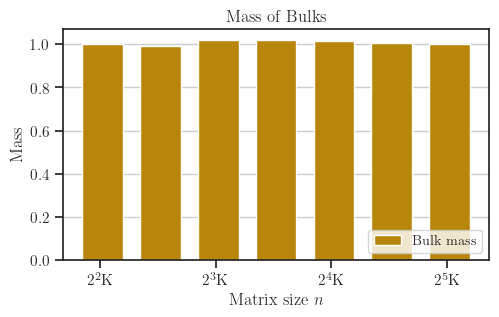

In [9]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, save=False, latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian-flow.pdf".


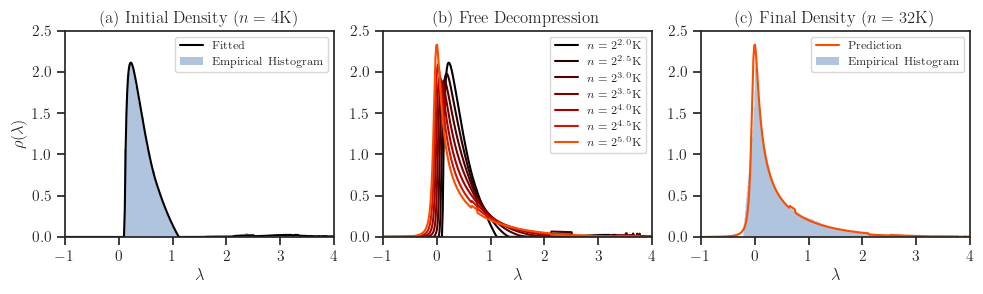

In [10]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx],
          # xlim=config['xlim'],
          xlim=(-1, 4),
          # ylim=config['ylim'],
          ylim=(0, 2.5),
          share_ax=False, layout='horizontal', title='Free Decompression',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          # nbins=config['nbins'],
          nbins=(80, 2000),
          label_mode=config['label_mode'],
          save=join(plot_dir, config['save_filename'] + '-flow.pdf'),
          latex=latex)

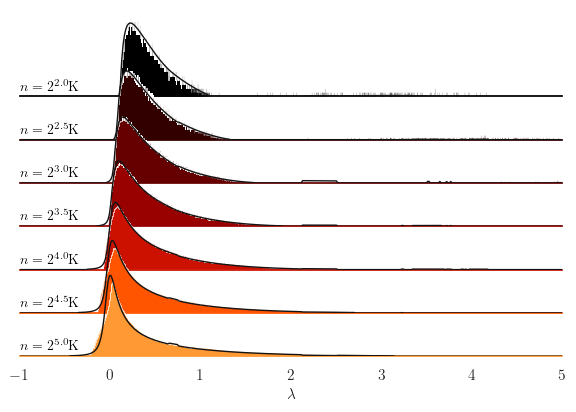

In [11]:
rho_ = numpy.copy(rho)
rho_[rho_ < 1e-2] = -1e-3

gray = 0.08
ridgeplot(fd_sizes, x=x, rho=rho_, eigs=eigs[start_idx:end_idx+1],
          log=False, scaley=False, hspace=-0.5, #-0.9,
          text_side='left',
          # xlim=config['xlim'],
          # xlim=(-1, 3),
          xlim=(-1, 5),
          ylim=(0, 2.5),
          rho_color=(gray, gray, gray),
          figsize=(7, 4.5),
          label_mode=config['label_mode'],
          latex=latex, title='',
          # save=join(plot_dir, config['save_filename'] + '-ridge.pdf'),
          nbins=2000)

# Debug

In [ ]:
%matplotlib qt
# %matplotlib inline

_ = af.debug_decompress(
    fd_sizes[0:],
    x=0.5,
    # x=1e-4,
    min_n_times=2000,
    newton_opt=newton_opt,
    # t_lim=[-0.05, 1.75],
    # t_lim=[0.0, 2.1],
    # re_lim=[-300, 0],
    # # # im_lim=[1e0, 9e2],
    # im_lim=[5e-6, 1e7],
)

# Hessian Index

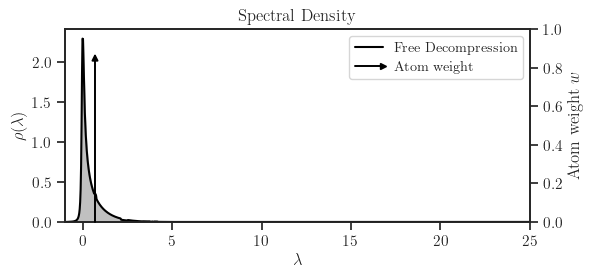

In [12]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = numpy.geomspace(sizes[start_idx], sizes[end_idx], 200)

# x span of decompression
# x_min = 1e-5
# x_max = 1e3
# x_min, x_max = config['xlim']
x_min, x_max = -1, 25
x = numpy.linspace(x_min, x_max, 1000)

newton_opt = dict(
    dt_max=0.0001,
    dt_min=1e-10,
    tol=1e-10,
    max_iter=200,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=1000,
    newton_opt=newton_opt, return_atoms=False, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

In [13]:
def density_index(rho, x, side='negative'):
    """Fraction of mass on x < 0 or x > 0 for each time row of rho."""
    rho = numpy.asarray(rho)
    x = numpy.asarray(x)

    if side == 'negative':
        mask = x < 0
    elif side == 'positive':
        mask = x > 0
    else:
        raise ValueError("side must be 'negative' or 'positive'.")

    side_mass = numpy.trapz(rho[:, mask], x[mask], axis=1)
    mass = numpy.trapz(rho[:, :], x, axis=1)
    index = side_mass / mass
    return index

def empirical_index(eigs):
    """Fraction of negative eigenvalues."""
    return numpy.array([
        numpy.mean(numpy.asarray(e) < 0.0)
        for e in eigs
    ])

idx_fd = density_index(rho, x, side='negative')
idx_emp = empirical_index(eigs[start_idx:end_idx+1])

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian-index.pdf".


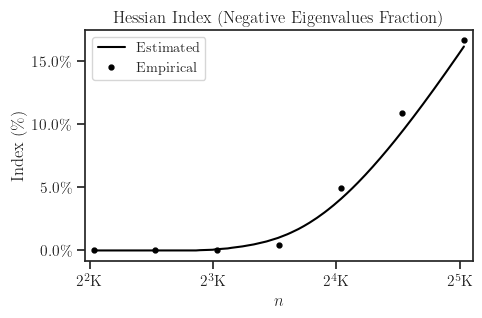

In [14]:
from freealg.visualization._api_plot_util import _k_pow2_formatter
import matplotlib.ticker as mticker

with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(fd_sizes, idx_fd * 100, color='black', label='Estimated')
    ax.plot(sizes[start_idx:end_idx+1], idx_emp * 100, 'o', markersize=3.5, color='black',
            label='Empirical')
    ax.set_xscale('log')
    ax.set_xlabel(r'$n$')
    ax.set_ylabel(r'Index (\%)')
    ax.set_xlim([fd_sizes[0]/1.05, fd_sizes[-1]*1.05])
    # ax.set_ylim(bottom=-4e-1)
    ax.legend(fontsize='small', loc='upper left')
    ax.set_title('Hessian Index (Negative Eigenvalues Fraction)')

    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))

    # ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))

    
    fig.patch.set_alpha(0)

    # Zero pad on left, right, and top of canvas
    import matplotlib.transforms as mtransforms
    fig.canvas.draw()
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    pad = 0.75 / 72.0
    bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                         bbox.x1+pad, bbox.y1+pad)

    full_save_filename = join(plot_dir, config['save_filename'] + '-index.pdf')
    save_status = True
    save_status = True
    texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                                  transparent_background=False, dpi=200,
                                  bbox_inches=bbox,
                                  show_and_save=save_status, verbose=True)

# Distributional Comparison (Table)

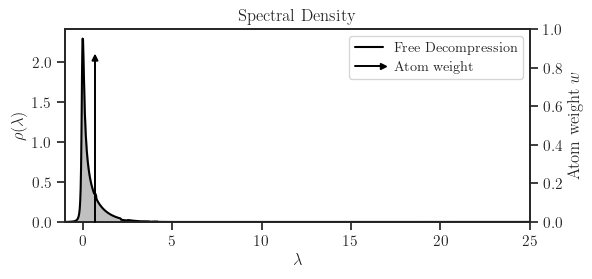

In [15]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
# x_min = 1e-5
# x_max = 1e3
# x_min, x_max = config['xlim']
x_min, x_max = -1, 25
x = numpy.linspace(x_min, x_max, 1000)

newton_opt = dict(
    dt_max=0.0001,
    dt_min=1e-10,
    tol=1e-10,
    max_iter=200,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=1000,
    newton_opt=newton_opt, return_atoms=False, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

In [22]:
from scipy.stats import wasserstein_distance, ks_2samp
from freealg import sample


def sample_tv(eig_emp, eig_fd, bins=100, xrange=None):
    """Histogram-based TV between two samples."""
    if xrange is None:
        lo = min(numpy.min(eig_emp), numpy.min(eig_fd))
        hi = max(numpy.max(eig_emp), numpy.max(eig_fd))
        xrange = (lo, hi)

    hist_emp, edges = numpy.histogram(
        eig_emp, bins=bins, range=xrange, density=True)
    hist_fd, _ = numpy.histogram(eig_fd, bins=edges, density=True)

    dx = numpy.diff(edges)
    return 0.5 * numpy.sum(numpy.abs(hist_emp - hist_fd) * dx)


def density_moment(rho_i, x, k):
    """Compute int x^k rho(x) dx."""
    return numpy.trapz((x**k) * rho_i, x)


def density_index(rho_i, x):
    """Mass of density on x < 0."""
    mask = x < 0
    return numpy.trapz(rho_i[mask], x[mask])


tv = []
ks = []
w1 = []
w1_norm = []
idx_fd = []
idx_err = []
mu1_err = []
mu2_err = []
std_err = []

for j, n in enumerate(fd_sizes):
    eig_emp = numpy.asarray(eigs[start_idx + j])
    rho_fd = rho[j]

    eig_fd = sample(
        x, rho_fd,
        num_pts=eig_emp.size,
        method='qmc',
        seed=start_idx + j,
    )

    tv_i = sample_tv(eig_emp, eig_fd, bins=100, xrange=(x[0], x[-1]))
    ks_i = ks_2samp(eig_emp, eig_fd).statistic

    w1_i = wasserstein_distance(eig_emp, eig_fd)
    L_i = numpy.ptp(eig_emp)
    w1_norm_i = w1_i / L_i

    idx_emp_i = numpy.mean(eig_emp < 0.0)
    idx_fd_i = density_index(rho_fd, x)
    idx_err_i = numpy.abs(idx_fd_i - idx_emp_i)

    mu1_emp = numpy.mean(eig_emp)
    mu2_emp = numpy.mean(eig_emp**2)
    std_emp = numpy.std(eig_emp)

    mu1_fd = density_moment(rho_fd, x, 1)
    mu2_fd = density_moment(rho_fd, x, 2)
    std_fd = numpy.sqrt(mu2_fd - mu1_fd**2)

    mu1_err_i = numpy.abs(mu1_fd - mu1_emp) / numpy.abs(mu1_emp)
    mu2_err_i = numpy.abs(mu2_fd - mu2_emp) / numpy.abs(mu2_emp)
    std_err_i = numpy.abs(std_fd - std_emp) / numpy.abs(std_emp)

    tv.append(tv_i)
    ks.append(ks_i)
    w1.append(w1_i)
    w1_norm.append(w1_norm_i)
    idx_fd.append(idx_fd_i)
    idx_err.append(idx_err_i)
    mu1_err.append(mu1_err_i)
    mu2_err.append(mu2_err_i)
    std_err.append(std_err_i)

tv = numpy.asarray(tv)
ks = numpy.asarray(ks)
w1 = numpy.asarray(w1)
w1_norm = numpy.asarray(w1_norm)
idx_fd = numpy.asarray(idx_fd)
idx_err = numpy.asarray(idx_err)
mu1_err = numpy.asarray(mu1_err)
mu2_err = numpy.asarray(mu2_err)
std_err = numpy.asarray(std_err)

print(
    f"{'n':>6}  {'TV':>5}  {'KS':>5}  {'W1/L':>8}  "
    f"{'idx FD':>8}  {'idx err':>8}  "
    f"{'mu1 err':>8}  {'mu2 err':>8}  {'std err':>8}"
)
print("-" * 81)

for j, n in enumerate(fd_sizes):
    print(
        f"{int(n):6d}  "
        f"{100*tv[j]:4.1f}%  "
        f"{100*ks[j]:4.1f}%  "
        f"{100*w1_norm[j]:7.2f}%  "
        f"{100*idx_fd[j]:7.1f}%  "
        f"{100*idx_err[j]:7.1f}%  "
        f"{100*mu1_err[j]:7.1f}%  "
        f"{100*mu2_err[j]:7.1f}%  "
        f"{100*std_err[j]:7.1f}%"
    )

     n     TV     KS      W1/L    idx FD   idx err   mu1 err   mu2 err   std err
---------------------------------------------------------------------------------
  4096   0.3%   0.4%     0.05%      0.0%      0.0%      0.3%      0.6%      0.3%
  5792   1.9%   1.2%     0.32%      0.0%      0.0%      3.5%      9.7%      6.1%
  8192   4.7%   3.0%     0.74%      0.1%      0.1%      8.5%      7.3%      0.9%
 11585   4.3%   2.9%     0.66%      1.0%      0.6%      9.0%      5.1%      0.1%
 16384   3.9%   2.4%     0.51%      4.2%      0.8%      6.8%      0.2%      2.0%
 23170   3.8%   2.1%     0.33%      9.6%      1.3%      2.1%      7.4%      4.9%
 32768   4.2%   2.8%     0.32%     16.3%      0.4%      3.5%     22.3%     13.0%


# Runtime

To correctly measure runtime, do these:

1. `ssh mm340`
2. Export these
   ```
       export OMP_NUM_THREADS=1
       export OPENBLAS_NUM_THREADS=1
       export MKL_NUM_THREADS=1
       export NUMEXPR_NUM_THREADS=1
   ```
3. In `newton_opt`, set
   ```
       parallel=False
       n_jobs=1
   ```

In [94]:
# ================
# set delta_ladder
# ================

def set_delta_ladder(delta_ladder_size, method, fit_degree=2):
    """
    To benchmakr with only ont evaluation of density at one
    delta distance, set af.delta_ladder, like

    >>> set_delta_ladder(delta_ladder_size=1, method='direct', fit_degree=2)

    To return back to previosu behavior, set

    >>> set_delta_ladder(delta_ladder_size=4, method='chebfit', fit_degree=2)
    """
    
    af.inv_stieltjes_opt['delta_ladder_size'] = delta_ladder_size
    af.inv_stieltjes_opt['method'] = method
    af.inv_stieltjes_opt['fit_degree'] = fit_degree
        
    delta_ladder_grid = inv_stieltjes_opt['delta_ladder_grid']
    delta_ladder_ratio = inv_stieltjes_opt['delta_ladder_ratio']
    delta_ladder_size = inv_stieltjes_opt['delta_ladder_size']
    
    # Type of grid to produces multiple deltas for Plemelj
    if delta_ladder_grid == 'geometric':
        af.delta_ladder = af.delta * (
                delta_ladder_ratio **
                numpy.arange(delta_ladder_size, dtype=int))
    elif delta_ladder_grid == 'linear':
        af.delta_ladder = af.delta * \
            numpy.arange(1, delta_ladder_size+1, dtype=int)

    print('\nChanged af.delta_ladder to:')
    print(af.delta_ladder)
    print('')

In [96]:
import time, resource

def cpu_total_with_children():
    self = resource.getrusage(resource.RUSAGE_SELF)
    kids = resource.getrusage(resource.RUSAGE_CHILDREN)
    return self.ru_utime + self.ru_stime + kids.ru_utime + kids.ru_stime

# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']

set_delta_ladder(delta_ladder_size=1, method='direct')

# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min, x_max = -1, 5
x = numpy.linspace(x_min, x_max, 200)

newton_opt = dict(
    dt_max=0.0001,
    dt_min=1e-10,
    tol=1e-10,
    max_iter=200,
    parallel=False,
    n_jobs=1,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

repeats = 5
fd_wall_times = numpy.zeros((fd_sizes.size,), dtype=float)
fd_proc_times = numpy.zeros((fd_sizes.size,), dtype=float)

i=0
print(f'Size: {fd_sizes[i]:>5d} ' + '.'*repeats, end='')
print(f' | fd wall time: {fd_wall_times[i]:>6.1f}'
      f' | fd proc time: {fd_proc_times[i]:>6.1f}'
      f' | direct proc time: {proc_times[i]:>9.1f}')

for i in numpy.arange(1, fd_sizes.size):

    print(f'Size: {fd_sizes[i]:>5d} ', end='')

    for j in range(repeats):

        print(f'.', end='')

        init_wall_time = time.time()
        init_proc_time = cpu_total_with_children()
        # init_proc_time = time.process_time()

        min_n_times = int(1000 * fd_sizes[i] / fd_sizes[-1])
        
        rho_bnch, x_bnch, _ = af.decompress(
            fd_sizes[0:i+1], x=x, kind='free', method='moc', min_n_times=min_n_times,
            newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
            verbose=False, plot=False, latex=latex)

        fd_wall_times[i] += time.time() - init_wall_time
        fd_proc_times[i] += cpu_total_with_children() - init_proc_time
        # fd_proc_times[i] += time.process_time() - init_proc_time

    fd_wall_times[i] /= repeats
    fd_proc_times[i] /= repeats

    print(f' | fd wall time: {fd_wall_times[i]:>6.1f}'
          f' | fd proc time: {fd_proc_times[i]:>6.1f}'
          f' | direct proc time: {proc_times[start_idx+i]:>9.1f}')

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)


Changed af.delta_ladder to:
[1.e-06]

Size:  4096 ..... | fd wall time:    0.0 | fd proc time:    0.0 | direct proc time:       0.9
Size:  5792 ..... | fd wall time:    4.2 | fd proc time:    4.8 | direct proc time:      91.9
Size:  8192 ..... | fd wall time:    5.5 | fd proc time:    6.1 | direct proc time:     271.9
Size: 11585 ..... | fd wall time:    9.6 | fd proc time:   10.2 | direct proc time:     759.4
Size: 16384 ..... | fd wall time:   15.6 | fd proc time:   16.2 | direct proc time:    2154.4
Size: 23170 ..... | fd wall time:   24.0 | fd proc time:   24.6 | direct proc time:    4755.3
Size: 32768 ..... | fd wall time:   35.4 | fd proc time:   36.0 | direct proc time:   14023.5

Changed af.delta_ladder to:
[1.e-06]

